In [22]:
import yfinance as yf                                                                                                                                                                                      
import pandas as pd                                                                                                                                                                                        
import matplotlib.pyplot as plt                                                                                                                                                                            
from sklearn.linear_model import LogisticRegression                                                                                                                                                        
from sklearn.preprocessing import StandardScaler                                                                                                                                                           
from sklearn.metrics import precision_score, roc_curve, roc_auc_score  

In [ ]:
sp500 = yf.Ticker("^GSPC")

In [24]:
sp500 = sp500.history(period="max")

In [25]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-01-20 00:00:00-05:00,6865.240234,6871.169922,6789.049805,6796.859863,5769500000,0.0,0.0
2026-01-21 00:00:00-05:00,6810.709961,6910.390137,6804.959961,6875.620117,5835520000,0.0,0.0
2026-01-22 00:00:00-05:00,6914.439941,6934.750000,6893.620117,6913.350098,5307580000,0.0,0.0


In [26]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-01-12 00:00:00-05:00', '2026-01-13 00:00:00-05:00',
               '2026-01-14 00:00:00-05:00', '2026-01-15 00:00:00-05:00',
               '2026-01-16 00:00:00-05:00', '2026-01-20 00:00:00-05:00',
               '2026-01-21 00:00:00-05:00', '2026-01-22 00:00:00-05:00',
               '2026-01-23 00:00:00-05:00', '2026-01-26 00:00:00-05:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=24633, freq=None)

In [27]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [28]:
sp500["Tommorow"] = sp500["Close"].shift(-1)

In [29]:
sp500["Target"] = (sp500["Tommorow"] > sp500["Close"]).astype(int)

In [30]:
sp500 = sp500.loc["1990-01-01":].copy()

In [31]:
sp500

,Open,High,Low,Close,Volume,Tommorow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-01-20 00:00:00-05:00,6865.240234,6871.169922,6789.049805,6796.859863,5769500000,6875.620117,1
2026-01-21 00:00:00-05:00,6810.709961,6910.390137,6804.959961,6875.620117,5835520000,6913.350098,1
2026-01-22 00:00:00-05:00,6914.439941,6934.750000,6893.620117,6913.350098,5307580000,6915.609863,1


In [32]:
horizons = [2,5,60,250,1000]
new_predictors = []

In [33]:
for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [34]:
sp500 = sp500.dropna()

In [35]:
sp500

,Open,High,Low,Close,Volume,Tommorow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-16 00:00:00-05:00,6960.540039,6967.299805,6925.089844,6940.009766,5356550000,6796.859863,0,0.999679,1.0,0.998502,2.0,1.016459,35.0,1.108289,144.0,1.378909,535.0
2026-01-20 00:00:00-05:00,6865.240234,6871.169922,6789.049805,6796.859863,5769500000,6875.620117,1,0.989579,0.0,0.983010,1.0,0.995256,35.0,1.084910,143.0,1.349826,534.0
2026-01-21 00:00:00-05:00,6810.709961,6910.390137,6804.959961,6875.620117,5835520000,6913.350098,1,1.005760,1.0,0.996942,2.0,1.006451,35.0,1.096929,143.0,1.364785,535.0


In [36]:
model = LogisticRegression(random_state=1,max_iter=1000)

In [ ]:
def predict(train, test, predictors, model):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train[predictors])
    test_scaled = scaler.transform(test[predictors])

    model.fit(train_scaled, train["Target"])

    probs = model.predict_proba(test_scaled)[:, 1]

    preds = (probs >= .6).astype(int)

    result = pd.DataFrame({
        "Target": test["Target"].values,
        "Predictions": preds,
        "Probabilities": probs        
    }, index = test.index)

    return result


In [38]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train,test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [39]:
predictions = backtest(sp500, model, new_predictors)
predictions["Predictions"].value_counts()

Predictions
0    5562
1      20
Name: count, dtype: int64

In [40]:
precision = precision_score(predictions["Target"], predictions["Predictions"])
print(f"Precision: {precision:.4f}") 

Precision: 0.5500


In [41]:
auc = roc_auc_score(predictions["Target"], predictions["Probabilities"])
print(f"AUC: {auc:.4f}")

AUC: 0.5210


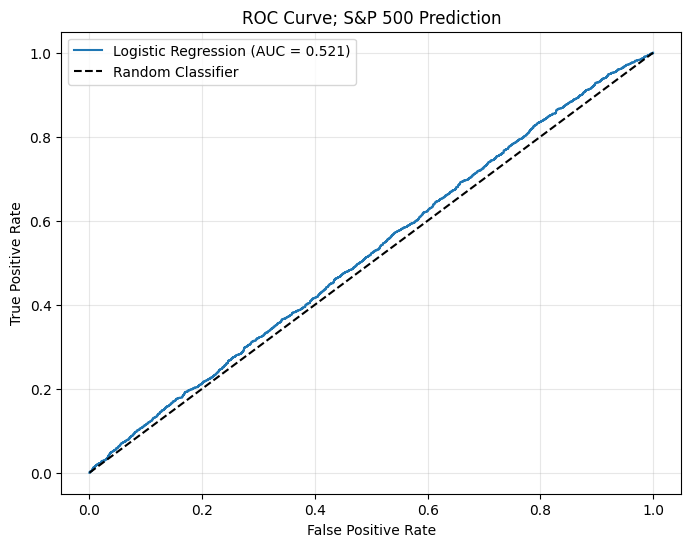

In [42]:
fpr, tpr, thresholds = roc_curve(predictions["Target"], predictions["Probabilities"])

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label = f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve; S&P 500 Prediction')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()